# 01 - Exploratory Data Analysis
## IEEE-CIS Fraud Detection Dataset

**Dataset**: Kaggle IEEE-CIS Fraud Detection (Vesta Corporation)
- 590K+ transactions with 434 features
- Binary classification: Fraud vs Legitimate
- Highly imbalanced (~3.5% fraud rate)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.insert(0, '..')

from src.config import (
    TRAIN_TRANSACTION_FILE,
    TRAIN_IDENTITY_FILE,
    TARGET_COL,
)

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', 50)

print("✅ Setup complete!")

✅ Setup complete!


## 1. Load Kaggle Data

In [ ]:
# Load transaction data
print(f"📂 Loading: {TRAIN_TRANSACTION_FILE.name}")
train_txn = pd.read_csv(TRAIN_TRANSACTION_FILE)
print(f"   Shape: {train_txn.shape}")

# Load identity data
print(f"\n📂 Loading: {TRAIN_IDENTITY_FILE.name}")
train_id = pd.read_csv(TRAIN_IDENTITY_FILE)
print(f"   Shape: {train_id.shape}")

# Merge datasets
print("\n🔗 Merging transaction + identity data...")
df = train_txn.merge(train_id, on='TransactionID', how='left')
print(f"   Final shape: {df.shape}")
print(f"   Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.0f} MB")

📂 Loading: train_transaction.csv
   Shape: (590540, 394)

📂 Loading: train_identity.csv
   Shape: (144233, 41)

🔗 Merging transaction + identity data...
   Final shape: (590540, 434)
   Memory usage: 2514 MB


In [ ]:
# Preview the data
print("📋 Sample transactions:")
df.head()

📋 Sample transactions:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,...,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


## 2. Target Variable Analysis

🎯 Target Distribution:
   Total transactions: 590,540
   Fraud: 20,663 (3.50%)
   Legitimate: 569,877 (96.50%)
   Imbalance ratio: 1:28


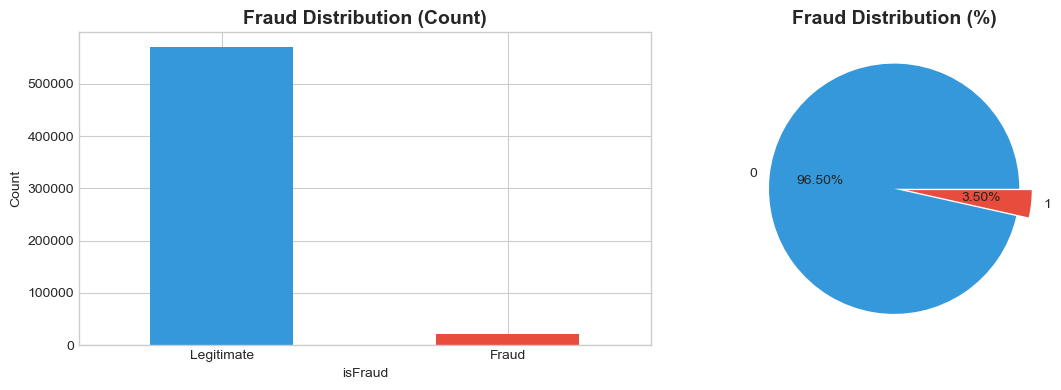

In [ ]:
# Fraud rate analysis
fraud_rate = df[TARGET_COL].mean()
fraud_count = df[TARGET_COL].sum()
legit_count = len(df) - fraud_count

print("🎯 Target Distribution:")
print(f"   Total transactions: {len(df):,}")
print(f"   Fraud: {fraud_count:,} ({fraud_rate:.2%})")
print(f"   Legitimate: {legit_count:,} ({1-fraud_rate:.2%})")
print(f"   Imbalance ratio: 1:{int(1/fraud_rate)}")

# Visualize
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#3498db', '#e74c3c']
df[TARGET_COL].value_counts().plot(kind='bar', ax=ax[0], color=colors)
ax[0].set_title('Fraud Distribution (Count)', fontsize=14, fontweight='bold')
ax[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
ax[0].set_ylabel('Count')

df[TARGET_COL].value_counts().plot(kind='pie', ax=ax[1], autopct='%1.2f%%', colors=colors, explode=[0, 0.1])
ax[1].set_title('Fraud Distribution (%)', fontsize=14, fontweight='bold')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 3. Transaction Amount Analysis

In [ ]:
# Transaction amount statistics
print("💰 Transaction Amount by Fraud Status:")
print(df.groupby(TARGET_COL)['TransactionAmt'].describe().round(2))

fraud_mean = df[df[TARGET_COL] == 1]['TransactionAmt'].mean()
legit_mean = df[df[TARGET_COL] == 0]['TransactionAmt'].mean()
print(f"\n💡 Insight: Fraud avg ${fraud_mean:.0f} vs Legitimate avg ${legit_mean:.0f}")

💰 Transaction Amount by Fraud Status:
            count    mean     std   min    25%   50%    75%       max
isFraud                                                              
0        569877.0  134.51  239.40  0.25  43.97  68.5  120.0  31937.39
1         20663.0  149.24  232.21  0.29  35.04  75.0  161.0   5191.00

💡 Insight: Fraud avg $149 vs Legitimate avg $135


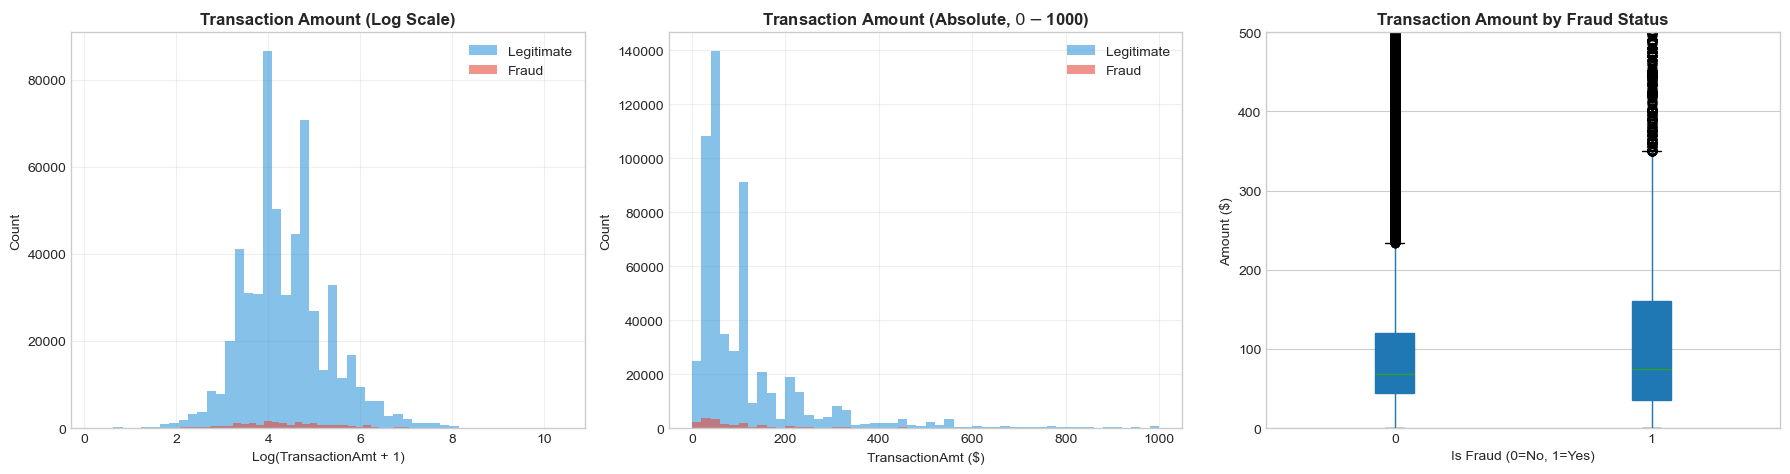

In [ ]:
# Distribution plots - Log scale, Absolute values, Box plot
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

colors = {'Legitimate': '#3498db', 'Fraud': '#e74c3c'}

# Plot 1: Log Scale Distribution
for fraud in [0, 1]:
    subset = df[df[TARGET_COL] == fraud]['TransactionAmt']
    label = 'Fraud' if fraud else 'Legitimate'
    ax[0].hist(np.log1p(subset), bins=50, alpha=0.6, label=label, color=colors[label])

ax[0].set_xlabel('Log(TransactionAmt + 1)')
ax[0].set_ylabel('Count')
ax[0].set_title('Transaction Amount (Log Scale)', fontsize=12, fontweight='bold')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Plot 2: Absolute Values Distribution (capped at $1000)
for fraud in [0, 1]:
    subset = df[df[TARGET_COL] == fraud]['TransactionAmt']
    label = 'Fraud' if fraud else 'Legitimate'
    ax[1].hist(subset, bins=50, alpha=0.6, label=label, color=colors[label], range=(0, 1000))

ax[1].set_xlabel('TransactionAmt ($)')
ax[1].set_ylabel('Count')
ax[1].set_title('Transaction Amount (Absolute, $0-$1000)', fontsize=12, fontweight='bold')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

# Plot 3: Box Plot
bp = df.boxplot(column='TransactionAmt', by=TARGET_COL, ax=ax[2], patch_artist=True)
ax[2].set_title('Transaction Amount by Fraud Status', fontsize=12, fontweight='bold')
ax[2].set_xlabel('Is Fraud (0=No, 1=Yes)')
ax[2].set_ylabel('Amount ($)')
ax[2].set_ylim(0, 500)
plt.suptitle('')

plt.tight_layout()
plt.show()

## 4. Feature Overview

In [ ]:
# Feature categories
print("📊 Feature Categories:")
print(f"   Total features: {len(df.columns)}")
print(f"   Numeric: {len(df.select_dtypes(include=[np.number]).columns)}")
print(f"   Categorical: {len(df.select_dtypes(include=['object']).columns)}")

# Column groups
v_cols = [c for c in df.columns if c.startswith('V')]
c_cols = [c for c in df.columns if c.startswith('C') and c[1:].isdigit()]
d_cols = [c for c in df.columns if c.startswith('D') and c[1:].isdigit()]
m_cols = [c for c in df.columns if c.startswith('M')]
id_cols = [c for c in df.columns if c.startswith('id_')]
card_cols = [c for c in df.columns if c.startswith('card')]

print(f"\n   V columns (Vesta features): {len(v_cols)}")
print(f"   C columns (count features): {len(c_cols)}")
print(f"   D columns (time delta): {len(d_cols)}")
print(f"   M columns (match features): {len(m_cols)}")
print(f"   Card columns: {len(card_cols)}")
print(f"   Identity columns: {len(id_cols)}")

📊 Feature Categories:
   Total features: 434
   Numeric: 403
   Categorical: 31

   V columns (Vesta features): 339
   C columns (count features): 14
   D columns (time delta): 15
   M columns (match features): 9
   Card columns: 6
   Identity columns: 38


## 5. Missing Values Analysis

❓ Missing Values Summary:
   Features with >50% missing: 214
   Features with >90% missing: 12
   Features with 0% missing: 20


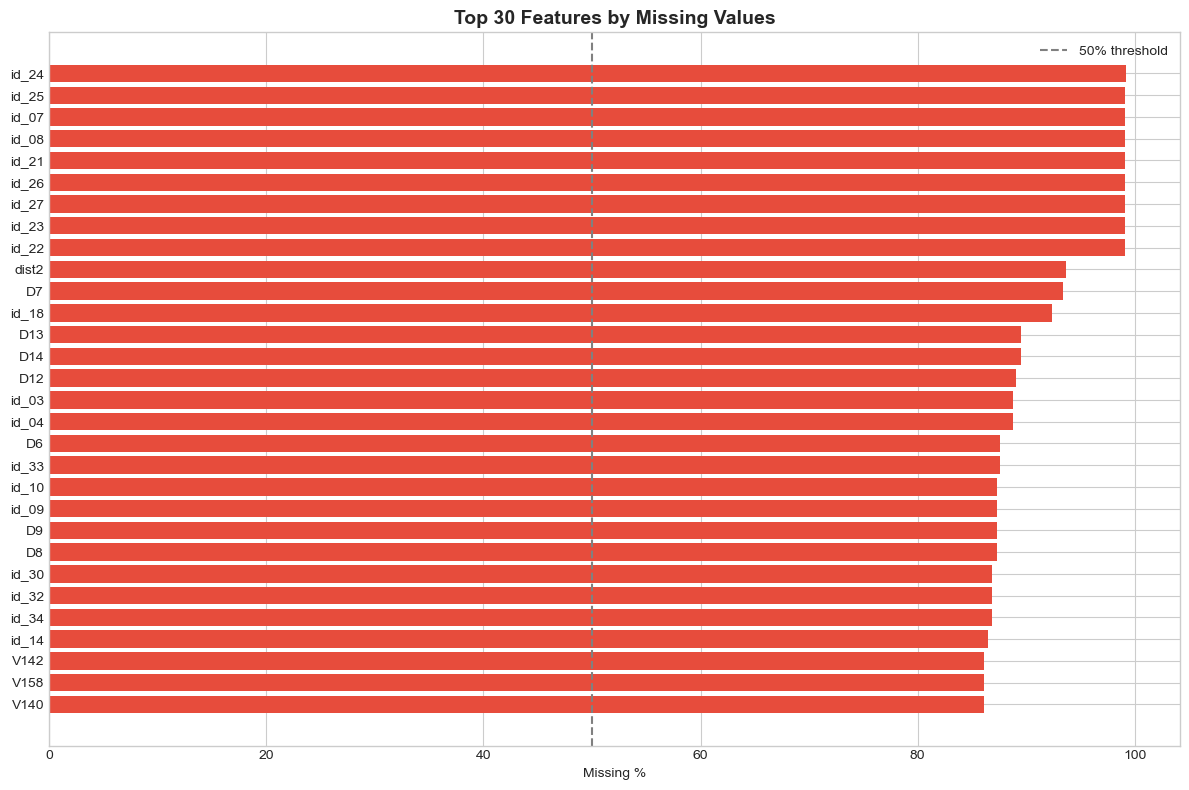

In [ ]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).sort_values(ascending=False)

print("❓ Missing Values Summary:")
print(f"   Features with >50% missing: {(missing_pct > 50).sum()}")
print(f"   Features with >90% missing: {(missing_pct > 90).sum()}")
print(f"   Features with 0% missing: {(missing_pct == 0).sum()}")

# Plot top 30 features with most missing values
top_missing = missing_pct[missing_pct > 0].head(30)

plt.figure(figsize=(12, 8))
plt.barh(range(len(top_missing)), top_missing.values, color='#e74c3c')
plt.yticks(range(len(top_missing)), top_missing.index)
plt.xlabel('Missing %')
plt.title('Top 30 Features by Missing Values', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.axvline(x=50, color='gray', linestyle='--', label='50% threshold')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Categorical Features

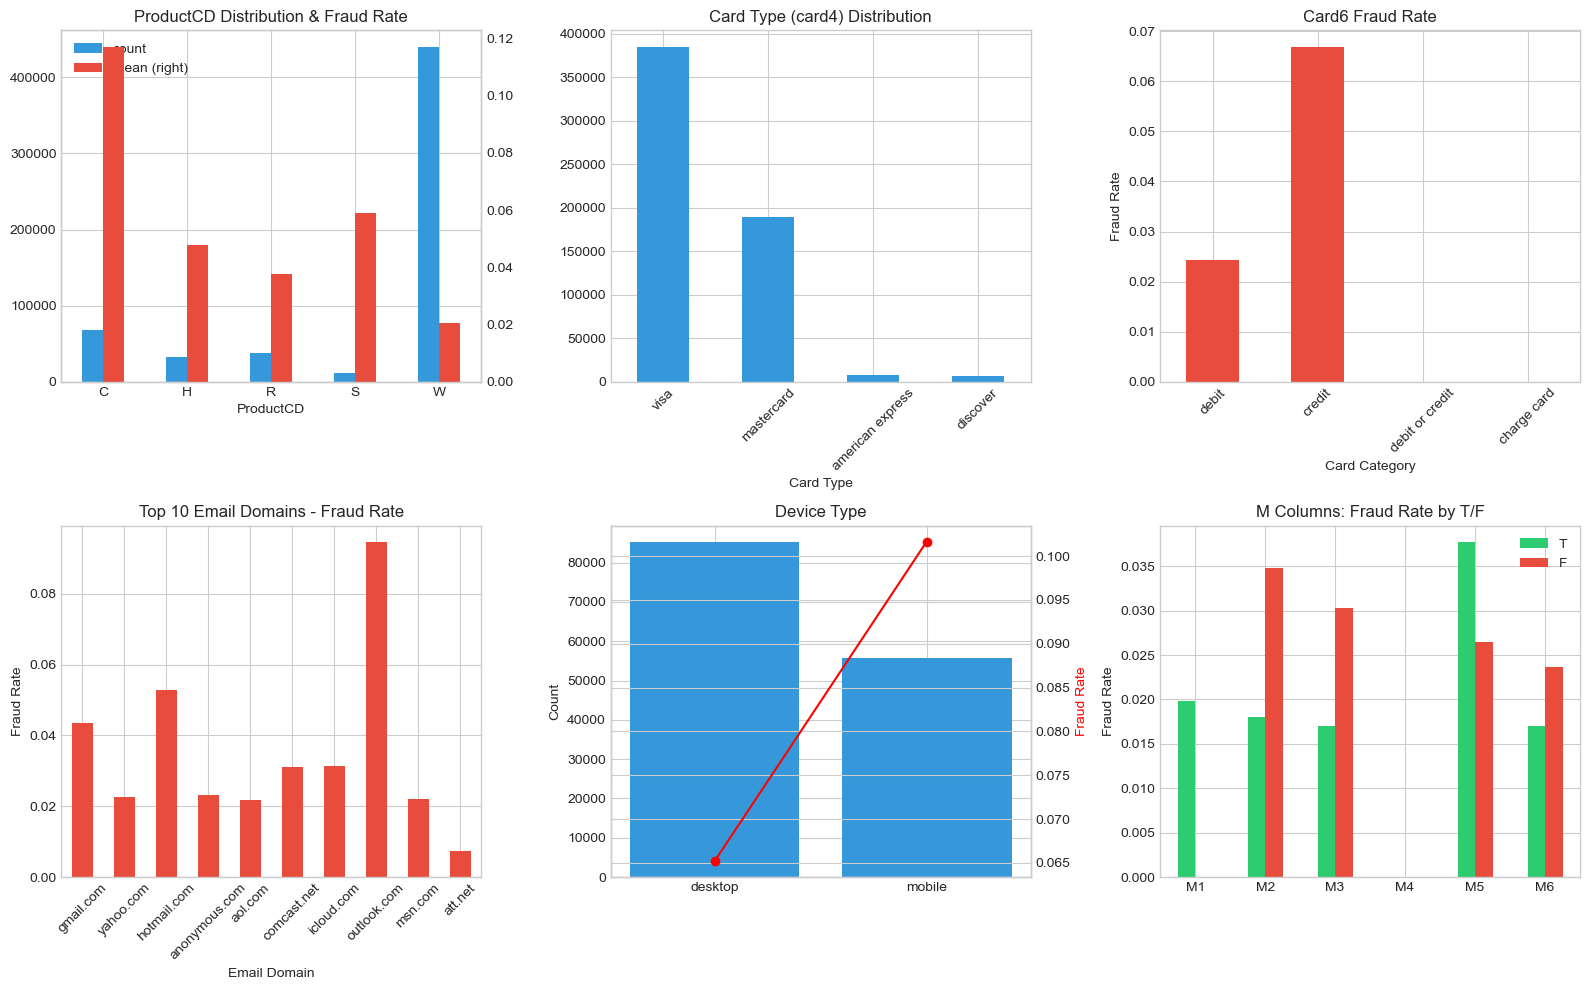

In [ ]:
# Key categorical features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ProductCD
ax = axes[0, 0]
df.groupby('ProductCD')[TARGET_COL].agg(['count', 'mean']).plot(kind='bar', secondary_y='mean', ax=ax, color=['#3498db', '#e74c3c'])
ax.set_title('ProductCD Distribution & Fraud Rate')
ax.set_xlabel('ProductCD')
ax.tick_params(axis='x', rotation=0)

# Card4 (card type)
ax = axes[0, 1]
card4_stats = df.groupby('card4')[TARGET_COL].agg(['count', 'mean']).sort_values('count', ascending=False)
card4_stats['count'].plot(kind='bar', ax=ax, color='#3498db')
ax.set_title('Card Type (card4) Distribution')
ax.set_xlabel('Card Type')
ax.tick_params(axis='x', rotation=45)

# Card6 (debit/credit)
ax = axes[0, 2]
card6_stats = df.groupby('card6')[TARGET_COL].agg(['count', 'mean']).sort_values('count', ascending=False)
card6_stats['mean'].plot(kind='bar', ax=ax, color='#e74c3c')
ax.set_title('Card6 Fraud Rate')
ax.set_xlabel('Card Category')
ax.set_ylabel('Fraud Rate')
ax.tick_params(axis='x', rotation=45)

# Email domains
ax = axes[1, 0]
email_stats = df.groupby('P_emaildomain')[TARGET_COL].agg(['count', 'mean']).sort_values('count', ascending=False).head(10)
email_stats['mean'].plot(kind='bar', ax=ax, color='#e74c3c')
ax.set_title('Top 10 Email Domains - Fraud Rate')
ax.set_xlabel('Email Domain')
ax.set_ylabel('Fraud Rate')
ax.tick_params(axis='x', rotation=45)

# DeviceType
ax = axes[1, 1]
device_stats = df.groupby('DeviceType')[TARGET_COL].agg(['count', 'mean']).dropna()
x = range(len(device_stats))
ax.bar(x, device_stats['count'], color='#3498db', label='Count')
ax2 = ax.twinx()
ax2.plot(x, device_stats['mean'], 'r-o', label='Fraud Rate')
ax.set_xticks(x)
ax.set_xticklabels(device_stats.index)
ax.set_title('Device Type')
ax.set_ylabel('Count')
ax2.set_ylabel('Fraud Rate', color='red')

# M columns (match features)
ax = axes[1, 2]
m_fraud_rates = {}
for col in ['M1', 'M2', 'M3', 'M4', 'M5', 'M6']:
    if col in df.columns:
        m_fraud_rates[col] = df.groupby(col)[TARGET_COL].mean().to_dict()
m_df = pd.DataFrame(m_fraud_rates).T
if 'T' in m_df.columns and 'F' in m_df.columns:
    m_df[['T', 'F']].plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
    ax.set_title('M Columns: Fraud Rate by T/F')
    ax.set_ylabel('Fraud Rate')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 7. Correlation Analysis

📈 Top Features Positively Correlated with Fraud:
   V257: 0.3831
   V246: 0.3669
   V244: 0.3641
   V242: 0.3606
   V201: 0.3280
   V200: 0.3188
   V189: 0.3082
   V188: 0.3036
   V258: 0.2972

📉 Top Features Negatively Correlated with Fraud:
   V30: -0.1031
   V69: -0.1045
   V91: -0.1055
   V29: -0.1079
   V90: -0.1102
   V49: -0.1109
   V48: -0.1158
   id_01: -0.1201
   D7: -0.1272
   D8: -0.1426


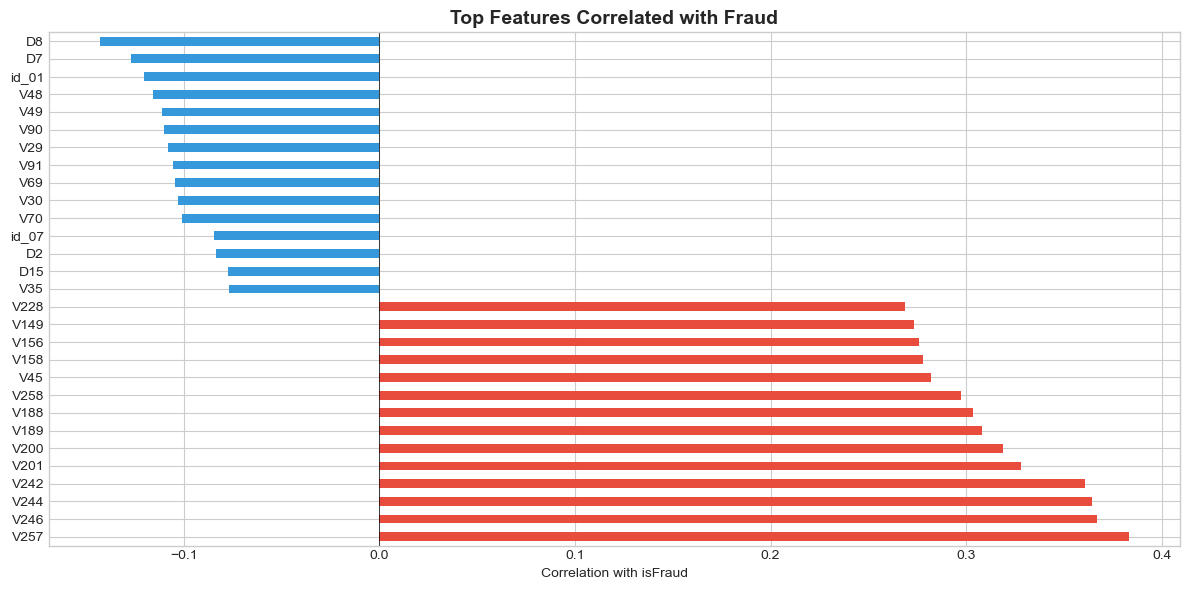

In [ ]:
# Correlation with target for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
correlations = df[numeric_cols].corrwith(df[TARGET_COL]).sort_values(ascending=False)

# Top positive and negative correlations
print("📈 Top Features Positively Correlated with Fraud:")
for feat, corr in correlations.head(10).items():
    if feat != TARGET_COL:
        print(f"   {feat}: {corr:.4f}")

print("\n📉 Top Features Negatively Correlated with Fraud:")
for feat, corr in correlations.tail(10).items():
    print(f"   {feat}: {corr:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
top_corr = pd.concat([correlations.head(15), correlations.tail(15)])
top_corr = top_corr[top_corr.index != TARGET_COL]
colors = ['#e74c3c' if x > 0 else '#3498db' for x in top_corr.values]
top_corr.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Correlation with isFraud')
ax.set_title('Top Features Correlated with Fraud', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## 8. Key Insights Summary

In [ ]:
print("=" * 60)
print("📋 KEY INSIGHTS FROM EDA")
print("=" * 60)
print(f"""
1. DATASET SIZE
   • {len(df):,} transactions with {len(df.columns)} features
   • Train/Identity merge covers all transactions

2. CLASS IMBALANCE
   • Fraud rate: {fraud_rate:.2%} (1:{int(1/fraud_rate)} ratio)
   • Requires: stratified sampling, AUC-PR metrics, threshold tuning

3. TRANSACTION AMOUNT
   • Fraud transactions slightly higher on average
   • Wide variance in both classes
   • Log transform recommended for modeling

4. MISSING VALUES
   • {(missing_pct > 50).sum()} features have >50% missing
   • Identity features have most missing (left join)
   • Strategy: Fill with -999 or categorical 'MISSING'

5. KEY FEATURES FOR FRAUD DETECTION
   • V-columns (Vesta proprietary) show high correlation
   • C-columns (count features) are predictive
   • Card and device features important for segmentation

6. NEXT STEPS
   • Feature engineering (time features, aggregations)
   • Model training with LightGBM
   • Threshold optimization for desired recall
""")
print("=" * 60)

📋 KEY INSIGHTS FROM EDA

1. DATASET SIZE
   • 590,540 transactions with 434 features
   • Train/Identity merge covers all transactions

2. CLASS IMBALANCE
   • Fraud rate: 3.50% (1:28 ratio)
   • Requires: stratified sampling, AUC-PR metrics, threshold tuning

3. TRANSACTION AMOUNT
   • Fraud transactions slightly higher on average
   • Wide variance in both classes
   • Log transform recommended for modeling

4. MISSING VALUES
   • 214 features have >50% missing
   • Identity features have most missing (left join)
   • Strategy: Fill with -999 or categorical 'MISSING'

5. KEY FEATURES FOR FRAUD DETECTION
   • V-columns (Vesta proprietary) show high correlation
   • C-columns (count features) are predictive
   • Card and device features important for segmentation

6. NEXT STEPS
   • Feature engineering (time features, aggregations)
   • Model training with LightGBM
   • Threshold optimization for desired recall

